# **Comparison between Centralized RAG with MergedRetriever versus Federated RAG**

**1. Centralized RAG:**
- Document chunking for fine-grained embeddings
- Embedding model selection
- Composite retrieval using LangChain MergerRetriever

2. **Federated RAG:**
- Complete data privacy with independent nodes
- Results-only communication
- EM and F1 evaluation metrics
- Synthesis and comparative analysis

In [ ]:
!pip install -qqq langchain faiss-cpu python-dotenv
!pip install -qqq -U langchain-openai
!pip install -qqq langchain-core langchain-openai langchain-community beautifulsoup4 requests
!pip install -qqq sentence-transformers scikit-learn nltk matplotlib

In [ ]:
import os
import sys
import re
import string
import time
from collections import Counter
from typing import List, Dict, Any
from langchain.text_splitter import CharacterTextSplitter
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain.docstore.document import Document
from langchain.chains import RetrievalQA
from langchain.retrievers import MergerRetriever
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

# For evaluation metrics
import nltk
import numpy as np

# Download NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

## Set OpenAI API key

In [ ]:
from google.colab import auth
from google.colab import userdata
import os

# Get the secret named "OPENAI_API_KEY" from Colab's secret store
api_key = userdata.get('OPENAI_API_KEY')

# Set it as an environment variable
#os.environ["OPENAI_API_KEY"] = "sk-xxx"
os.environ["OPENAI_API_KEY"] = api_key

print("OpenAI API key loaded")

OpenAI API key loaded


# **Load Knowledge Based Documents**

In [ ]:
def chunk_documents(docs, chunk_size=1100, chunk_overlap=200):
    # Split each LangChain Docs into smaller chunks for embeddings.
    splitter = CharacterTextSplitter(
        separator="\n",
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )
    chunks = []
    for doc in docs:
        # Split page_contents
        pieces = splitter.split_text(doc.page_content)
        for piece in pieces:
            chunks.append(Document(page_content=piece, metadata=doc.metadata))
    return chunks

In [ ]:
def load_text_file(file_path, source_name):
    #Load content from a text file and create a LangChain Document.
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            content = file.read()

        # Create document with metadata
        doc = Document(
            page_content=content,
            metadata={"source": file_path, "title": source_name}
        )
        print(f"Loaded {len(content)} characters from {file_path}", file=sys.stderr)
        return [doc]  # Return as list for consistency

    except Exception as e:
        print(f"Error loading {file_path}: {e}", file=sys.stderr)
        return []

def get_federated_docs_from_files(file_paths_and_names):
    all_docs = []
    for file_path, source_name in file_paths_and_names:
        docs = load_text_file(file_path, source_name)
        all_docs.extend(docs)
    return all_docs

In [ ]:
# Load and process Hull documents
print("Loading and processing Hull documents...")
hull_files = [
    ("./data/hull.txt", "Hull MSc AI Online")
]

hull_docs = get_federated_docs_from_files(hull_files)
hull_chunks = chunk_documents(hull_docs)
print(f"Hull: {len(hull_chunks)} chunks created")

Loading and processing Hull documents...
Hull: 6 chunks created


Loaded 4676 characters from ./data/hull.txt


In [ ]:
# Load and process Keele documents
print("Loading and processing Keele documents...")
keele_files = [
    ("./data/keele.txt", "Keele MSc Computer Science with AI")
]

keele_docs = get_federated_docs_from_files(keele_files)
keele_chunks = chunk_documents(keele_docs)
print(f"Keele: {len(keele_chunks)} chunks created")

Loading and processing Keele documents...
Keele: 3 chunks created


Loaded 2739 characters from ./data/keele.txt


# **Part 1: Centralized RAG with MergerRetriever**

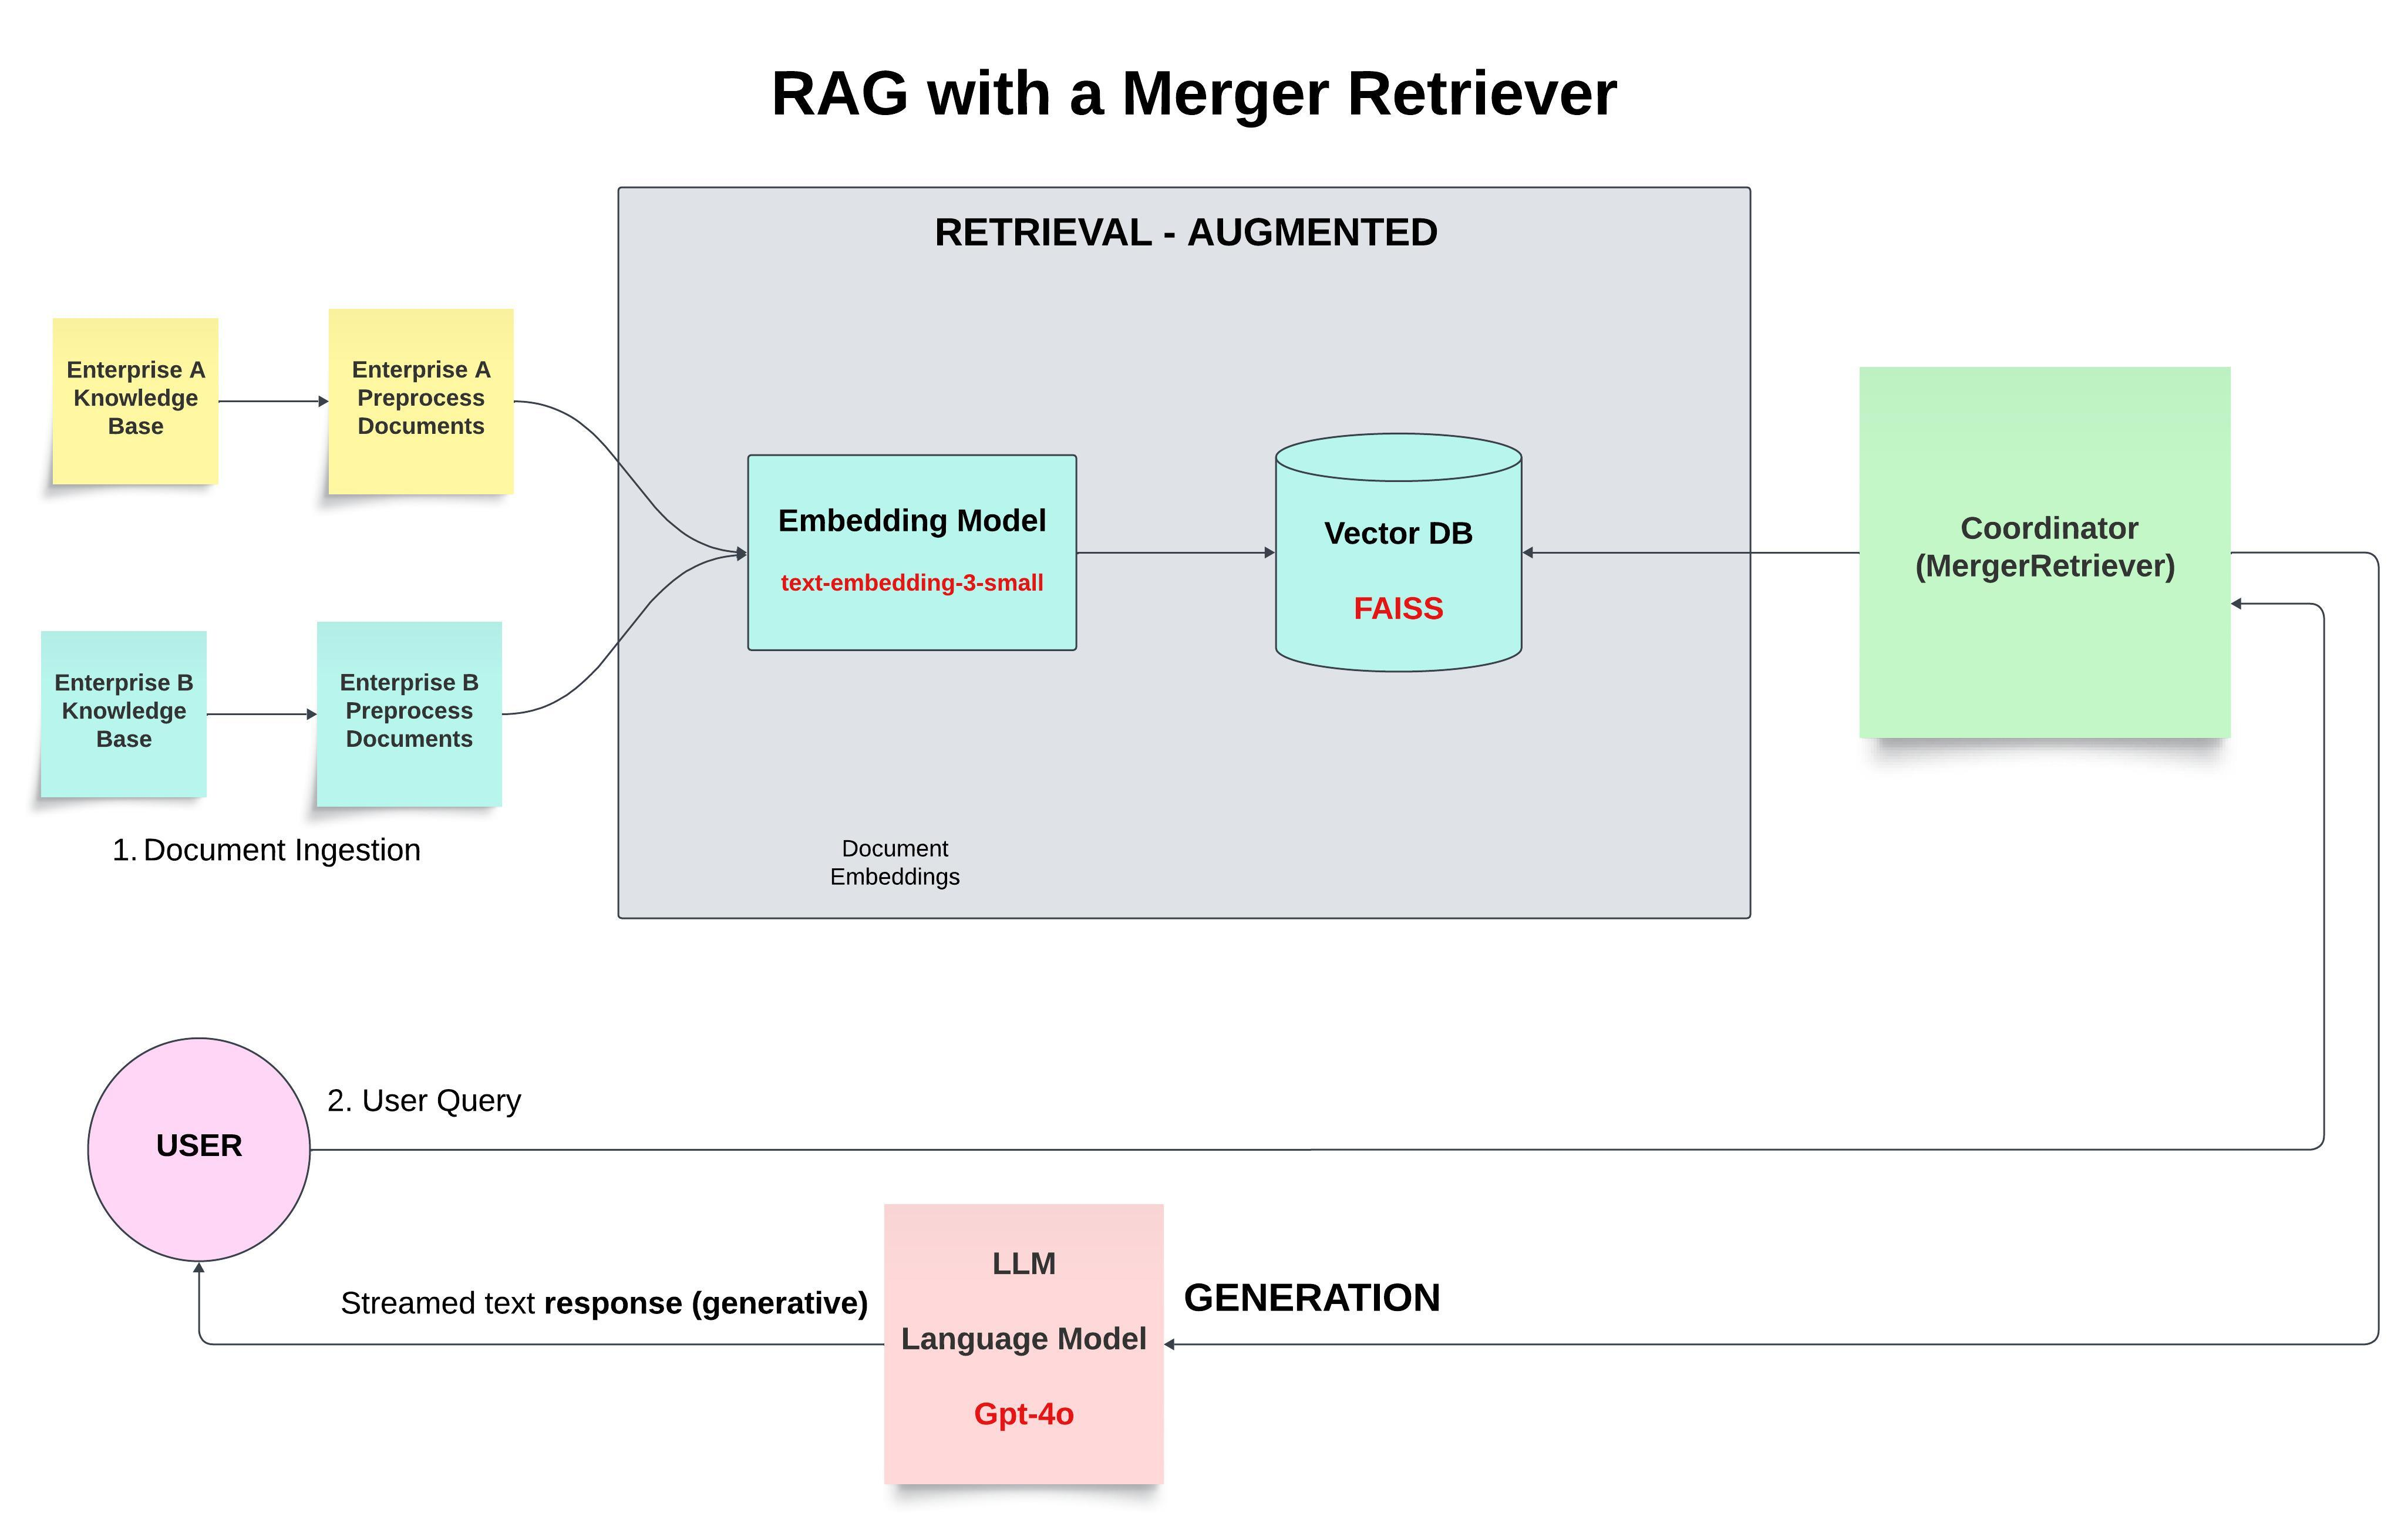

In [ ]:
# Create embeddings and vector stores
print("Creating embeddings and vector stores...")
embeddings = OpenAIEmbeddings()

# Create separate vector stores for each institution
hull_vectorstore = FAISS.from_documents(hull_chunks, embeddings)
keele_vectorstore = FAISS.from_documents(keele_chunks, embeddings)

print("Vector stores created successfully!")

Creating embeddings and vector stores...
Vector stores created successfully!


In [ ]:
# Create separated retrievers
hull_retriever = hull_vectorstore.as_retriever(search_kwargs={"k": 5})
keele_retriever = keele_vectorstore.as_retriever(search_kwargs={"k": 5})

# Create merged retriever for RAG with MergerRetriever
merger_retriever = MergerRetriever(retrievers=[hull_retriever, keele_retriever])

print("Retrievers created successfully!")

Retrievers created successfully!


In [ ]:
# Create QA chain with the merged retriever
llm = ChatOpenAI(temperature=0, model_name="gpt-4o")
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=merger_retriever,
    return_source_documents=True)

print("QA chain created successfully!")

QA chain created successfully!


# Define evaluation questions with corresponding ground truth answers

In [ ]:
# Define evaluation questions and corresponding ground truth answers
questions = [
    "What is the total cost of the MSc Artificial Intelligence online programme at the University of Hull?",
    "How long does the MSc Artificial Intelligence online programme at the University of Hull take to complete?",
    "What is the phone number for enquiries about online courses at the University of Hull?",
    "What is the email address for enquiries about online courses at the University of Hull?",
    "When are the start dates for the MSc Artificial Intelligence online programme at the University of Hull?",
    "How much is the acceptance fee required to secure a place for Hull online courses, and how is it applied to the tuition fees?",
    "What are the minimum academic entry requirements for applicants holding a degree for the Hull MSc AI programme?",
    "What is the credit for each module in the University of Hull MSc Artificial Intelligence programme?",
    "What is the alumni tuition fee discount offered by Keele University for this online MSc programme, and what is the reduced total fee?",
    "How many times per year can students start the Keele online MSc Computer Science with Artificial Intelligence programme?",
    "Would an IELTS overall score of 6.0 meet the English language requirements for the online MSc Computer Science with Artificial Intelligence at Keele University?",
    "What is the total programme fee for the online MSc Computer Science with Artificial Intelligence at Keele University?",
    "How long does the online MSc Computer Science with Artificial Intelligence at Keele University take to complete?",
    "What is the email address for enquiries about online programmes at Keele University?",
    "How many credits are required to complete the online MSc Computer Science with Artificial Intelligence at Keele University?"
]

# Correct answers based on context
ground_truths = [
    "The total cost of the MSc Artificial Intelligence online programme at the University of Hull is £8,950",
    "The MSc Artificial Intelligence online programme at the University of Hull takes 24 months (two years) to complete on a part-time basis",
    "The phone number for enquiries about online courses at the University of Hull is +44 (0)1482 251819",
    "The email address for enquiries about online courses at the University of Hull is enquiries-online@hull.ac.uk",
    "The start dates of the MSc Artificial Intelligence online programme at the University of Hull are January, May, and September. The next start date is 22 September 2025.",
    "At the University of Hull, The acceptance fee required to secure a place for Hull online courses is £350. This fee must be paid within two weeks of the date on your offer letter.",
    "For the University of Hull MSc AI programme, Applicants holding a degree should have or be about to complete a minimum 2:2 undergraduate degree",
    "Each module in the MSc Artificial Intelligence online programme at the University of Hull is worth 630 credits",
    "Keele University offers a 10% alumni tuition fee discount on this online MSc programme, reducing the total fee to £6,696",
    "Students can start the Keele University online MSc Computer Science with Artificial Intelligence programme six times per year",
    "Yes. Keele University requires an IELTS overall score of 6.0 with no component below 5.5 meets the programme's English language requirement.",
    "The total programme fee for the online MSc Computer Science with Artificial Intelligence at Keele University is £7,440",
    "The online MSc Computer Science with Artificial Intelligence at Keele University is designed to be completed in 24 months (two years) part-time",
    "The email address for enquiries about online programmes at Keele University is enrolments@online.keele.ac.uk",
    "The online MSc Computer Science with Artificial Intelligence at Keele University is a 180-credit programme"
]

print(f"Test Dataset: {len(questions)} questions with ground truth answers")

Test Dataset: 15 questions with ground truth answers


## 1A. Evaluate EM Score and F1 Score of Centralized RAG

In [ ]:
# Centralized RAG system using MergerRetriever
print("Setting up Centralized RAG with MergerRetriever...")

embeddings = OpenAIEmbeddings(model="text-embedding-3-small") # Initialize embeddings

# Create separate vector stores
hull_index = FAISS.from_documents(hull_chunks, embeddings)
keele_index = FAISS.from_documents(keele_chunks, embeddings)

# Create individual retrievers
k_docs = 5
hull_retriever = hull_index.as_retriever(search_kwargs={"k": k_docs})
keele_retriever = keele_index.as_retriever(search_kwargs={"k": k_docs})

# Create merged retriever (traditional approach)
combined_retriever = MergerRetriever(retrievers=[hull_retriever, keele_retriever])

# Create QA chain
llm = ChatOpenAI(model_name="gpt-4o", temperature=0.3)
traditional_qa = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=combined_retriever,
    return_source_documents=True
)

print("Traditional Federated RAG ready!")

Setting up Centralized RAG with MergerRetriever...
Traditional Federated RAG ready!


In [ ]:
# Evaluation functions
def normalize_answer(s):
    #Normalize answer for evaluation
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)

    def white_space_fix(text):
        return ' '.join(text.split())

    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))

def exact_match_score(prediction, ground_truth):
    #Calculate Exact Match score
    return normalize_answer(prediction) == normalize_answer(ground_truth)

def f1_score_func(prediction, ground_truth):
    #Calculate F1 score
    prediction_tokens = normalize_answer(prediction).split()
    ground_truth_tokens = normalize_answer(ground_truth).split()

    if len(prediction_tokens) == 0 or len(ground_truth_tokens) == 0:
        return int(prediction_tokens == ground_truth_tokens)

    common_tokens = Counter(prediction_tokens) & Counter(ground_truth_tokens)
    num_same = sum(common_tokens.values())

    if num_same == 0:
        return 0

    precision = 1.0 * num_same / len(prediction_tokens)
    recall = 1.0 * num_same / len(ground_truth_tokens)
    f1 = (2 * precision * recall) / (precision + recall)

    return f1

def evaluate_answers(predictions, ground_truths):
    #Evaluate list of predictions against ground truths
    em_scores = []
    f1_scores = []

    for pred, gt in zip(predictions, ground_truths):
        em_scores.append(exact_match_score(pred, gt))
        f1_scores.append(f1_score_func(pred, gt))

    return {
        'exact_match': np.mean(em_scores),
        'f1': np.mean(f1_scores),
        'em_scores': em_scores,
        'f1_scores': f1_scores
    }

In [ ]:
# Test Centralized RAG
print("Testing Centralized RAG with MergerRetriever \n")
print("=" * 80)

traditional_predictions = []
traditional_results = []

for i, (question, ground_truth) in enumerate(zip(questions[:8], ground_truths[:8]), 1):  # Test first 8 questions
    print(f"\nQuestion {i}: {question}")

    start_time = time.time()
    result = traditional_qa({"query": question})
    response_time = time.time() - start_time

    prediction = result['result']
    sources_used = len(result['source_documents'])

    # Calculate scores
    em_score = exact_match_score(prediction, ground_truth)
    f1_score = f1_score_func(prediction, ground_truth)

    traditional_predictions.append(prediction)
    traditional_results.append({
        "question": question,
        "prediction": prediction,
        "expected": ground_truth,
        "em_score": em_score,
        "f1_score": f1_score,
        "response_time": response_time,
        "sources_used": sources_used
    })

    print(f"Prediction: {prediction}")
    print(f"Ground Truth: {ground_truth}")
    print(f"Exact Match: {em_score}, F1 Score: {f1_score:.2f}")
    print("-" * 80)

    time.sleep(1)  # Rate limiting

# Calculate overall metrics for traditional approach
traditional_metrics = evaluate_answers(traditional_predictions, ground_truths[:8])
print(f"\nTraditional Federated RAG Results:")
print(f"Overall EM: {traditional_metrics['exact_match']:.3f}")
print(f"Overall F1: {traditional_metrics['f1']:.3f}")

Testing Centralized RAG with MergerRetriever 


Question 1: What is the total cost of the MSc Artificial Intelligence online programme at the University of Hull?


/tmp/ipython-input-15-424257740.py:12: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  result = traditional_qa({"query": question})


Prediction: The total cost of the MSc Artificial Intelligence online programme at the University of Hull is £8,950. This includes a £350 acceptance fee.
Ground Truth: The total cost of the MSc Artificial Intelligence online programme at the University of Hull is £8,950
Exact Match: False, F1 Score: 0.85
--------------------------------------------------------------------------------

Question 2: How long does the MSc Artificial Intelligence online programme at the University of Hull take to complete?
Prediction: The MSc Artificial Intelligence online programme at the University of Hull takes two years to complete on a part-time basis.
Ground Truth: The MSc Artificial Intelligence online programme at the University of Hull takes 24 months (two years) to complete on a part-time basis
Exact Match: False, F1 Score: 0.94
--------------------------------------------------------------------------------

Question 3: What is the phone number for enquiries about online courses at the University 

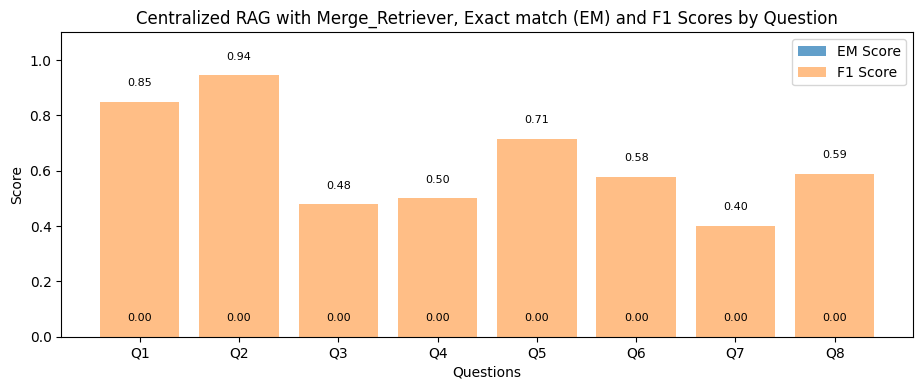

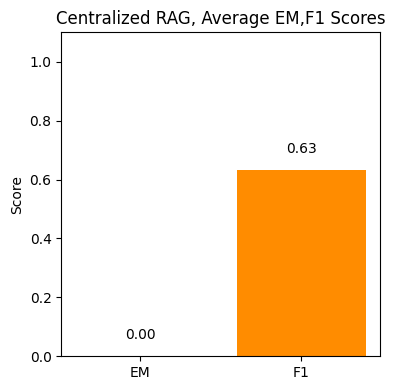

In [ ]:
# Visualize Centralized RAG results
em_scores_trad = traditional_metrics['em_scores']
f1_scores_trad = traditional_metrics['f1_scores']
avg_em_trad = traditional_metrics['exact_match']
avg_f1_trad = traditional_metrics['f1']

plt.figure(figsize=(18, 4))

#Plot individual scores
plt.subplot(1, 2, 1)
question_ids = [f"Q{i+1}" for i in range(len(em_scores_trad))]
bars1 = plt.bar(question_ids, em_scores_trad, alpha=0.7, label='EM Score')
bars2 = plt.bar(question_ids, f1_scores_trad, alpha=0.5, label='F1 Score')
plt.ylim(0, 1.1)
plt.xlabel('Questions')
plt.ylabel('Score')
plt.title('Centralized RAG with Merge_Retriever, Exact match (EM) and F1 Scores by Question')
plt.legend()

#Add score values above each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.05,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('Centralized RAG with MergerRetriever_em_f1_by_question.jpg', format='jpg', dpi=300)
plt.show()

# Plot average EM & F1 in a separate square figure
plt.figure(figsize=(4, 4))
bars3 = plt.bar(['EM', 'F1'], [avg_em_trad, avg_f1_trad], color=['darkblue', 'darkorange'])
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Centralized RAG, Average EM,F1 Scores')
for bar in bars3:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + .05, f'{h:.2f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig('Centralized_RAG_em_f1_average.jpg', format='jpg', dpi=300)
plt.show()

## 1B. Evaluate Synthesis Capabilities, Comparative Analysis, Completeness of Centralized RAG

In [ ]:
# QUESTIONS

test_questions = [
    # Direct Cost Comparisons
    "Compare the total program costs between Hull's MSc AI Online (£8,950) and Keele's MSc Computer Science with AI programs.",
    "What are all the different pricing options and payment methods available across both Hull and Keele AI programs?",

    # Program Structure and Flexibility
    "Compare the start dates and flexibility between Hull's three annual starts (January, May, September) and Keele's six starts per year.",
    "How do the study durations differ - Hull's structured 2-year part-time vs Keele's flexible self-paced approach?",

    # Technical Requirements and Skills
    "What programming languages and technical skills are covered across both programs - Hull's AI focus vs Keele's broader coverage?",
    "Compare the technical requirements and software needs between Hull's online platform and Keele's Canvas LMS with additional software.",

    # Assessment and Academic Approach
    "How do assessment methods differ - Hull's 100% coursework with no exams vs Keele's varied assessment methods?",
    "Compare the module structures - Hull's 5 specific AI modules vs Keele's broader computer science curriculum with AI specialization.",

    # Entry Requirements and Accessibility
    "Compare entry requirements - Hull's 2:2 STEM degree requirement vs Keele's acceptance of work experience in computing/IT roles.",
    "Which program is more accessible to career changers - Hull's academic focus vs Keele's industry experience pathway?",

    # Industry Connections and Career Focus
    "Compare industry partnerships - Hull's connections with global tech companies vs Keele's Knowledge Transfer Partnership with Bentley Motors.",
    "How do career preparation approaches differ between Hull's AI specialization and Keele's broader computer science foundation?",

    # Support and Student Experience
    "Compare student support systems - Hull's WhatsApp/phone support vs Keele's Canvas platform and email-based assistance.",
    "What are the combined advantages of studying at either institution for international students?",

    # Comprehensive Analysis Questions
    "For a working professional with no computer science background, which program offers better entry pathways and support?",
    "Create a decision matrix comparing cost, flexibility, technical depth, and career outcomes for both programs.",
    "What unique value propositions does each program offer, and how do they complement the AI education landscape?",
    "For someone seeking maximum technical breadth vs deep AI specialization, how do these programs compare?",

    # Privacy-Preserving Synthesis
    "Based on aggregated insights from both institutions, what trends emerge in online AI education delivery?",
    "Without exposing raw institutional data, what can you conclude about the relative strengths of each approach to AI education?"
]

print(f"Created {len(test_questions)} questions")

Created 20 questions


In [ ]:
# REFINED GROUND TRUTH: Answers that demonstrate superior synthesis capabilities
ground_truth_answers = [
    # Direct Cost Comparisons
    "Hull offers a fixed £8,950 total cost with clear payment structure (6 installments available), while Keele has variable pricing with module-by-module payment options. Hull provides cost predictability, while Keele offers payment flexibility. Both accept government postgraduate loans for UK/EU students.",
    "Combined payment methods include: Hull - online via Convera GlobalPay, phone with credit/debit card, bank transfer, 6 installment options; Keele - module-by-module payments, government loans, installment plans. Both offer flexible payment timing aligned with study progression.",

    # Program Structure and Flexibility
    "Hull provides 3 structured starts annually (January, May, September) with fixed 2-year timeline, while Keele offers 6 flexible starts per year allowing students to begin within weeks and progress at their own pace. Keele provides superior scheduling flexibility for working professionals.",
    "Hull follows a structured 2-year part-time program with clear milestones and cohort progression, while Keele allows self-paced study that can be completed faster or slower based on individual circumstances. Hull suits structured learners; Keele accommodates varied life situations.",

    # Technical Requirements and Skills
    "Hull focuses on AI-specific programming within 5 specialized modules (AI Foundations, Machine Learning & Deep Learning, Applied AI, etc.), while Keele provides broader technical foundation including HTML, JavaScript, Java, MATLAB, R, and Python across computer science curriculum. Keele offers wider programming exposure; Hull provides deeper AI specialization.",
    "Hull uses standard online platform with basic computer requirements, while Keele requires Canvas LMS plus specialized software: Anaconda for programming, XAMPP for web technologies, WEKA for data analytics. Keele demands higher technical setup but provides more hands-on tool experience.",

    # Assessment and Academic Approach
    "Hull uses 100% coursework assessment with no exams (60% assignments, 40% dissertation), benefiting students with exam anxiety. Keele employs varied assessment including online quizzes, reports, essays, case studies, projects, portfolios, and presentations. Hull favors continuous assessment; Keele accommodates diverse learning styles.",
    "Hull offers 5 focused AI modules: AI Foundations, Machine Learning & Deep Learning, Ethical AI, Applied AI, and Research Project. Keele provides broader computer science foundation with AI specialization including web technologies, databases, user interaction design, and software engineering. Hull is AI-specialized; Keele is comprehensive.",

    # Entry Requirements and Accessibility
    "Hull requires Honours degree at 2:2+ in STEM or closely related subject, with consideration for relevant professional experience. Keele accepts either academic qualifications OR graduate-level work experience in computing/IT/data roles. Keele provides more accessible entry pathways for career changers.",
    "Keele is more accessible to career changers through work experience pathway and broader foundational curriculum, while Hull requires stronger academic background but offers more focused AI specialization. Keele suits diverse backgrounds; Hull suits academically prepared students.",

    # Industry Connections and Career Focus
    "Hull maintains connections with global tech companies and provides broad industry exposure, while Keele has specific Knowledge Transfer Partnership with Bentley Motors Ltd offering direct automotive AI experience. Hull provides wider industry access; Keele offers targeted partnership benefits.",
    "Hull prepares AI specialists through focused curriculum and industry connections, while Keele develops well-rounded computer scientists with AI capabilities through broader technical foundation. Hull creates AI experts; Keele produces versatile technologists.",

    # Support and Student Experience
    "Hull offers multi-channel support including WhatsApp (+44 7360 538906), phone (+44 1482 251 819), and email (enquiries-online@hull.ac.uk), while Keele provides Canvas platform integration and email support (enrolments@online.keele.ac.uk). Hull offers more immediate communication options; Keele integrates support within learning platform.",
    "Combined advantages include: 100% online delivery from both institutions, no campus attendance required, global accessibility, UK university credentials, government loan eligibility (UK/EU), flexible payment options, and internationally recognized qualifications. Both serve global markets effectively.",

    # Comprehensive Analysis
    "Keele is better suited for non-CS professionals through work experience entry pathway, broader foundational curriculum, and self-paced progression. Hull requires stronger academic preparation but offers more focused AI specialization. Keele provides better transition support; Hull assumes stronger technical foundation.",
    "COST: Hull £8,950 fixed vs Keele variable pricing | FLEXIBILITY: Hull 3 starts/structured vs Keele 6 starts/self-paced | TECHNICAL DEPTH: Hull AI-focused vs Keele broad CS foundation | CAREER OUTCOMES: Hull AI specialist vs Keele versatile technologist | ENTRY: Hull degree required vs Keele experience accepted",
    "Hull offers deep AI specialization with structured progression and no-exam assessment, ideal for focused AI career development. Keele provides comprehensive computer science foundation with AI specialization and maximum flexibility, suitable for diverse career paths. Together they serve different market segments in AI education.",
    "For technical breadth, Keele excels with comprehensive programming languages, web technologies, databases, and software engineering alongside AI. For AI depth, Hull provides focused specialization in machine learning, deep learning, ethical AI, and applied AI. Choice depends on career goals: generalist vs specialist.",

    # Privacy-Preserving Synthesis
    "Emerging patterns include: flexible start dates becoming standard, mixed assessment methods preferred over traditional exams, industry partnerships increasingly valuable, self-paced learning gaining popularity, broad technical foundations combined with AI specialization, and global accessibility prioritized in program design.",
    "Analysis reveals complementary approaches: one institution emphasizes deep specialization with structured delivery, while the other provides comprehensive foundation with maximum flexibility. Both maintain high academic standards while serving different student populations and career objectives, strengthening the overall AI education ecosystem."
]

print(f"Created {len(ground_truth_answers)} refined ground truth answers demonstrating superior synthesis")
print(f"Questions and answers match: {len(test_questions) == len(ground_truth_answers)}")

Created 20 refined ground truth answers demonstrating superior synthesis
Questions and answers match: True


In [ ]:
# Test Centralized RAG with Merged Retriever system with first 5 questions
print("Testing RAG with Merged Retriever (Sample Questions):")
print("=" * 60)

merger_results = []
for i in range(min(5, len(test_questions))):
    question = test_questions[i]
    print(f"\nQuestion {i+1}: {question}")
    result = qa_chain({"query": question})
    print(f"Answer: {result['result']}")
    print(f"Expected: {ground_truth_answers[i]}")
    print(f"Sources: {[doc.metadata['source'] for doc in result['source_documents']]}")
    print("-" * 50)

    merger_results.append({
        "question": question,
        "answer": result['result'],
        "expected": ground_truth_answers[i],
        "sources": [doc.metadata['source'] for doc in result['source_documents']]
    })

Testing RAG with Merged Retriever (Sample Questions):

Question 1: Compare the total program costs between Hull's MSc AI Online (£8,950) and Keele's MSc Computer Science with AI programs.
Answer: The total program cost for Hull's MSc in Artificial Intelligence (Online) is £8,950. For Keele's MSc Computer Science with Artificial Intelligence, the total cost is £7,440. Therefore, Keele's program is £1,510 less expensive than Hull's program.
Expected: Hull offers a fixed £8,950 total cost with clear payment structure (6 installments available), while Keele has variable pricing with module-by-module payment options. Hull provides cost predictability, while Keele offers payment flexibility. Both accept government postgraduate loans for UK/EU students.
Sources: ['./data/hull.txt', './data/keele.txt', './data/hull.txt', './data/keele.txt', './data/hull.txt', './data/keele.txt', './data/hull.txt', './data/hull.txt']
--------------------------------------------------

Question 2: What are all t

# ================================================================================================================================================================

# **Part 2: True Federated RAG (Privacy-Preserving Approach)**

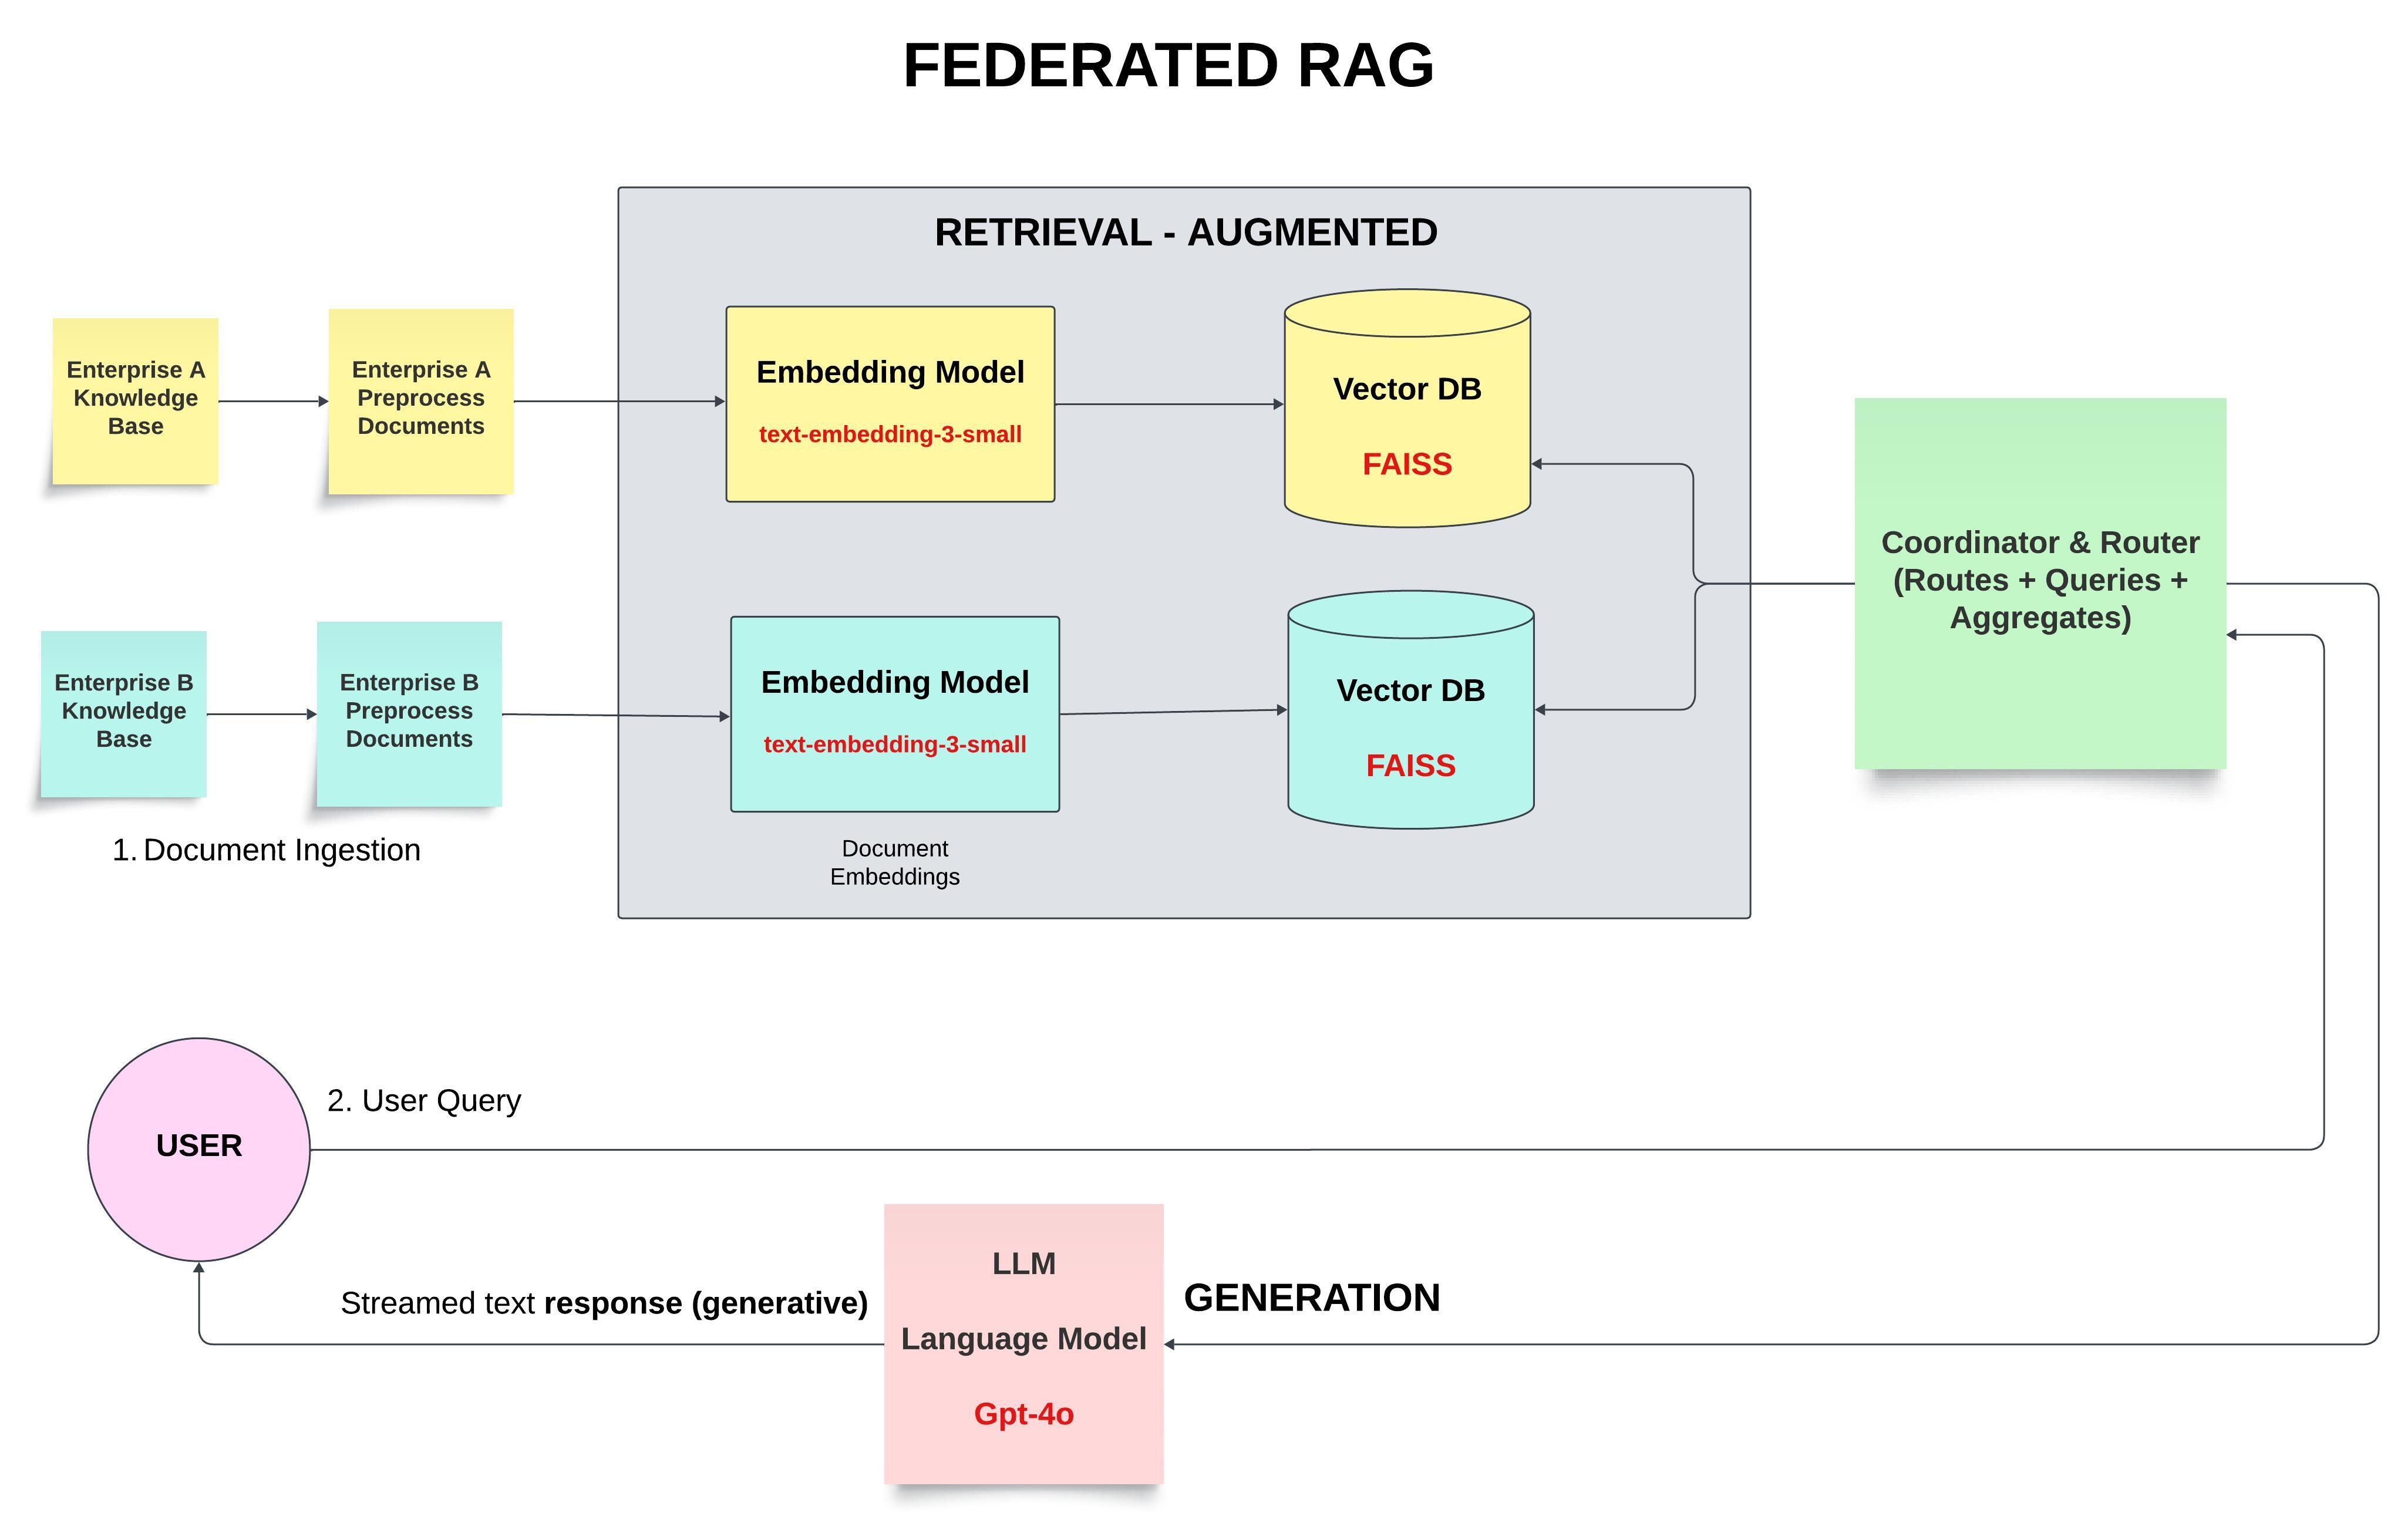

## 2A. Evaluate EM Score and F1 Score of Federated RAG

In [ ]:
class FederatedNode:
    """Independent federated node with private data and local retrieval
       MSc Artificial Intelligence online at University of Hull &
       MSc Computer Science with Artificial Intelligence online at Keele University"""

    def __init__(self, name: str, documents: List[Document], embeddings_model: str = "text-embedding-3-small"):
        self.name = name
        self.documents = documents
        self.embeddings = OpenAIEmbeddings(model=embeddings_model)
        self.vector_store = None
        self.retriever = None
        self.is_initialized = False

    def initialize_node(self, k_docs: int = 5):
        """Initialize the federated node with private data"""
        print(f"Initializing {self.name} node (PRIVATE DATA)...")

        # Build local vector store (PRIVATE - never shared)
        self.vector_store = FAISS.from_documents(self.documents, self.embeddings)
        self.retriever = self.vector_store.as_retriever(search_kwargs={"k": k_docs})

        self.is_initialized = True
        print(f"{self.name} node ready ({len(self.documents)} private chunks)")

    def local_retrieve(self, query: str) -> List[Dict[str, Any]]:
        """Perform local retrieval and return ONLY results (no raw data access)"""
        if not self.is_initialized:
            raise ValueError(f"{self.name} node not initialized")

        # Local retrieval (data never leaves this node)
        local_docs = self.retriever.get_relevant_documents(query)

        # Return only processed results (no raw vector store access)
        results = []
        for i, doc in enumerate(local_docs):
            results.append({
                "content": doc.page_content[:500] + "..." if len(doc.page_content) > 500 else doc.page_content,
                "source": doc.metadata.get("source", "Unknown"),
                "node": self.name,
                "rank": i + 1
            })

        return results

class TrueFederationCoordinator:
    """Coordinates federated queries without accessing raw data from any node"""

    def __init__(self, nodes: List[FederatedNode], llm_model: str = "gpt-4o", temperature: float = 0.3):
        self.nodes = nodes
        self.llm = ChatOpenAI(model_name=llm_model, temperature=temperature)

    def federated_query(self, query: str) -> Dict[str, Any]:
        """Execute federated query across all nodes"""
        all_results = []
        node_responses = {}

        # Step 1: Distribute query to all federated nodes
        for node in self.nodes:
            node_results = node.local_retrieve(query)
            node_responses[node.name] = node_results
            all_results.extend(node_results)

        # Step 2: Aggregate results (no raw data access)
        aggregated_context = self._aggregate_results(all_results)

        # Step 3: Generate response
        prompt = f"""Based on the federated search results from multiple universities, provide a precise and accurate answer to: {query}

Federated Results:
{aggregated_context}

Requirements:
- Be precise and factual
- Include specific numbers, dates, and details when available
- If information is from a specific university, mention it
- Keep the answer focused and direct"""

        response = self.llm.predict(prompt)

        return {
            "query": query,
            "answer": response,
            "node_responses": node_responses,
            "total_sources": len(all_results)
        }

    def _aggregate_results(self, results: List[Dict[str, Any]]) -> str:
        """Aggregate results from all federated nodes"""
        aggregated = ""
        for i, result in enumerate(results[:8], 1):  # Limit to top 8 results
            aggregated += f"\n[{result['node']} - Rank {result['rank']}]: {result['content']}\n"
        return aggregated

In [ ]:
# Create Federated RAG system
print("Setting up True Federated RAG...\n")

# Create independent federated nodes (using existing chunks)
hull_node = FederatedNode("Hull University", hull_chunks, "text-embedding-3-small")
hull_node.initialize_node(k_docs=5)

print()

keele_node = FederatedNode("Keele University", keele_chunks, "text-embedding-3-small")
keele_node.initialize_node(k_docs=5)

print()

# Create Federation Coordinator (no direct data access)
print("Creating True Federation Coordinator...")
true_coordinator = TrueFederationCoordinator([hull_node, keele_node], "gpt-4o", 0.3)

print("\nTrue Federated RAG System Ready!")
print("Each node maintains complete data privacy")
print("Only final results are shared between nodes")

Setting up True Federated RAG...

Initializing Hull University node (PRIVATE DATA)...
Hull University node ready (6 private chunks)

Initializing Keele University node (PRIVATE DATA)...
Keele University node ready (3 private chunks)

Creating True Federation Coordinator...

True Federated RAG System Ready!
Each node maintains complete data privacy
Only final results are shared between nodes


In [ ]:
# Test Federated RAG
print("Testing Fully Separated Federated RAG (Privacy-Preserving)\n")
print("=" * 80)

true_fed_predictions = []
true_fed_results = []

for i, (question, ground_truth) in enumerate(zip(questions[8:], ground_truths[8:]), 9):  # Test remaining questions
    print(f"\nQuestion {i}: {question}")

    start_time = time.time()
    result = true_coordinator.federated_query(question)
    response_time = time.time() - start_time

    prediction = result['answer']
    sources_used = result['total_sources']

    # Calculate scores
    em_score = exact_match_score(prediction, ground_truth)
    f1_score = f1_score_func(prediction, ground_truth)

    true_fed_predictions.append(prediction)
    true_fed_results.append({
        "question": question,
        "prediction": prediction,
        "expected": ground_truth,
        "em_score": em_score,
        "f1_score": f1_score,
        "response_time": response_time,
        "sources_used": sources_used
    })

    print(f"Prediction: {prediction}")
    print(f"Ground Truth: {ground_truth}")
    print(f"Exact Match: {em_score}, F1 Score: {f1_score:.2f}")
    print("-" * 80)

    time.sleep(1)  # Rate limiting

# Calculate overall metrics for federated RAG approach
true_fed_metrics = evaluate_answers(true_fed_predictions, ground_truths[8:])
print(f"\nFully Separated Federated RAG Results:")
print(f"Overall EM: {true_fed_metrics['exact_match']:.3f}")
print(f"Overall F1: {true_fed_metrics['f1']:.3f}")

Testing Fully Separated Federated RAG (Privacy-Preserving)


Question 9: What is the alumni tuition fee discount offered by Keele University for this online MSc programme, and what is the reduced total fee?
Prediction: Keele University offers a 10% alumni tuition fee discount for its online MSc Computer Science with Artificial Intelligence programme. The total fee for the programme is £7,440, and with the alumni discount, the reduced total fee is £6,696.
Ground Truth: Keele University offers a 10% alumni tuition fee discount on this online MSc programme, reducing the total fee to £6,696
Exact Match: False, F1 Score: 0.55
--------------------------------------------------------------------------------

Question 10: How many times per year can students start the Keele online MSc Computer Science with Artificial Intelligence programme?
Prediction: Students can start the Keele online MSc Computer Science with Artificial Intelligence programme six times per year.
Ground Truth: Students can 

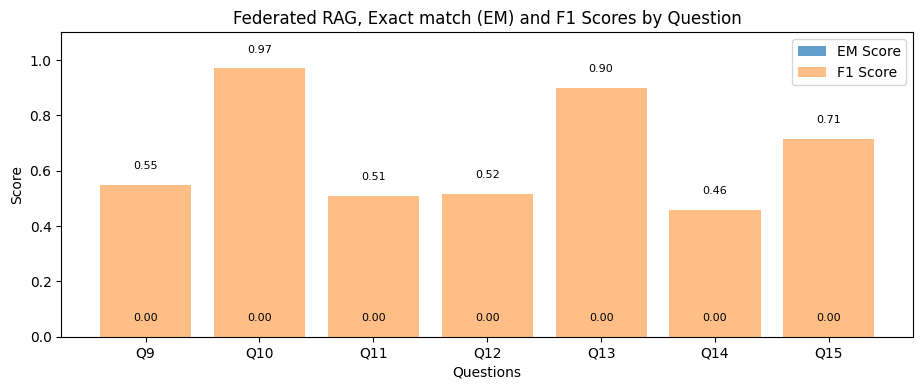

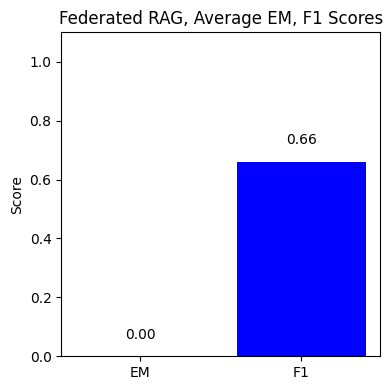

In [ ]:
# Visualize True Federated RAG results
em_scores_true = true_fed_metrics['em_scores']
f1_scores_true = true_fed_metrics['f1_scores']
avg_em_true = true_fed_metrics['exact_match']
avg_f1_true = true_fed_metrics['f1']

plt.figure(figsize=(18, 4))

# Plot individual scores
plt.subplot(1, 2, 1)
question_ids = [f"Q{i+9}" for i in range(len(em_scores_true))]
bars1 = plt.bar(question_ids, em_scores_true, alpha=0.7, label='EM Score')
bars2 = plt.bar(question_ids, f1_scores_true, alpha=0.5, label='F1 Score')
plt.ylim(0, 1.1)
plt.xlabel('Questions')
plt.ylabel('Score')
plt.title('Federated RAG, Exact match (EM) and F1 Scores by Question')
plt.legend()

# Add score values above each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.05,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('Federated_RAG_em_f1_by_question.jpg', format='jpg', dpi=300)
plt.show()

# Plot average EM & F1 in a separate square figure
plt.figure(figsize=(4, 4))
bars3 = plt.bar(['EM', 'F1'], [avg_em_true, avg_f1_true], color=['lightblue', 'blue'])
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Federated RAG, Average EM, F1 Scores')
for bar in bars3:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + .05, f'{h:.2f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig('Fully_Separated_Federated_RAG_em_f1_average.jpg', format='jpg', dpi=300)
plt.show()

## 2B. Evaluate Synthesis Capabilities, Comparative Analysis, Completeness of Federated RAG

In [ ]:
class FederatedRAGNode:
    # federated RAG node that keeps data private and only shares results

    def __init__(self, node_id: str, documents: List[Document], embeddings_model):
        self.node_id = node_id
        self.documents = documents
        self.embeddings_model = embeddings_model
        self.vectorstore = None
        self.retriever = None
        self.qa_chain = None
        self._setup_node()

    def _setup_node(self):
        #Initialize the node's vector store and QA chain
        # Create chunks
        chunks = chunk_documents(self.documents)

        # Create vector store
        self.vectorstore = FAISS.from_documents(chunks, self.embeddings_model)
        self.retriever = self.vectorstore.as_retriever(search_kwargs={"k": 5})

        # Create QA chain
        llm = ChatOpenAI(temperature=0, model_name="gpt-4o")
        self.qa_chain = RetrievalQA.from_chain_type(
            llm=llm,
            chain_type="stuff",
            retriever=self.retriever,
            return_source_documents=True
        )

        print(f"Node {self.node_id} initialized with {len(chunks)} chunks")

    def query(self, question: str) -> Dict[str, Any]:
        """Process a query and return results (without exposing raw data)."""
        result = self.qa_chain({"query": question})

        # Return only the answer and confidence score, not the raw documents
        return {
            "node_id": self.node_id,
            "answer": result["result"],
            "confidence": self._calculate_confidence(result),
            "source_count": len(result["source_documents"])
        }

    def _calculate_confidence(self, result) -> float:
        # Calculate a simple confidence score based on source documents
        source_count = len(result["source_documents"])
        max_sources = 5  # Our retriever returns max 5 documents
        return min(source_count / max_sources, 1.0)

In [ ]:
# Create federated nodes
print("Creating federated RAG nodes...")

# Create individual nodes
hull_node = FederatedRAGNode("Hull", hull_docs, embeddings)
keele_node = FederatedRAGNode("Keele", keele_docs, embeddings)

# Store nodes in a list for easy management
federated_nodes = [hull_node, keele_node]

print("Federated nodes created successfully!")

Creating federated RAG nodes...
Node Hull initialized with 6 chunks
Node Keele initialized with 3 chunks
Federated nodes created successfully!


In [ ]:
class EnhancedFederatedCoordinator:
    # Enhanced Federated coordinator with synthesis capabilities for comparative questions.

    def __init__(self, nodes: List[FederatedRAGNode]):
        self.nodes = nodes
        self.llm = ChatOpenAI(temperature=0.1, model_name="gpt-3.5-turbo")  #higher temp for creativity

    def federated_query(self, question: str) -> Dict[str, Any]:
        #Send query to all nodes and aggregate results with enhanced synthesis.
        # Get results from all nodes
        node_results = []
        for node in self.nodes:
            result = node.query(question)
            node_results.append(result)

        # Enhanced aggregation for better synthesis
        aggregated_result = self._enhanced_aggregate_results(question, node_results)

        return {
            "question": question,
            "individual_results": node_results,
            "aggregated_answer": aggregated_result
        }

    def _enhanced_aggregate_results(self, question: str, node_results: List[Dict]) -> str:
        # Enhanced aggregation with superior synthesis for comparative questions.
        # Detect question type for better synthesis
        question_lower = question.lower()
        is_comparative = any(word in question_lower for word in ['compare', 'difference', 'vs', 'versus', 'between', 'differ'])
        is_aggregative = any(word in question_lower for word in ['both', 'all', 'total', 'across', 'list', 'combined'])
        is_contextual = any(word in question_lower for word in ['which', 'better', 'best', 'recommend', 'choose', 'suitable'])
        is_analytical = any(word in question_lower for word in ['analyze', 'trends', 'patterns', 'insights', 'conclude'])

        # Create enhanced synthesis prompt based on question type
        if is_comparative:
            synthesis_prompt = f"""Question: {question}

I need to provide a detailed comparative analysis based on these institutional responses:

"""
        elif is_aggregative:
            synthesis_prompt = f"""Question: {question}

I need to aggregate and synthesize information from these institutional sources:

"""
        elif is_contextual:
            synthesis_prompt = f"""Question: {question}

I need to provide contextual recommendations based on these institutional insights:

"""
        elif is_analytical:
            synthesis_prompt = f"""Question: {question}

I need to analyze patterns and provide insights based on these institutional data points:

"""
        else:
            synthesis_prompt = f"""Question: {question}

I have received information from multiple institutional sources:

"""
        # Add node results with enhanced context
        for result in node_results:
            synthesis_prompt += f"{result['node_id']} University (confidence: {result['confidence']:.2f}, sources: {result['source_count']}):\n{result['answer']}\n\n"

        # Enhanced synthesis instructions based on question type
        if is_comparative:
            synthesis_prompt += """Please provide a comprehensive comparison that:
1. Highlights key differences and similarities between the institutions
2. Structures the comparison around the specific aspects mentioned in the question
3. Provides context for why these differences matter
4. Offers balanced analysis of each institution's strengths"""
        elif is_aggregative:
            synthesis_prompt += """Please combine all relevant information into a comprehensive answer that:
1. Includes all mentioned items, options, or details from both institutions
2. Organizes information logically and clearly
3. Identifies patterns or commonalities across sources
4. Provides complete coverage without redundancy"""
        elif is_contextual:
            synthesis_prompt += """Please provide contextual recommendations that:
1. Consider the specific criteria and context in the question
2. Weigh the advantages and disadvantages of each option
3. Provide clear guidance based on different scenarios or needs
4. Explain the reasoning behind recommendations"""
        elif is_analytical:
            synthesis_prompt += """Please provide analytical insights that:
1. Identify patterns and trends across the institutional data
2. Draw meaningful conclusions without exposing raw data
3. Highlight implications and significance of findings
4. Provide strategic or forward-looking perspectives"""
        else:
            synthesis_prompt += """Please synthesize the information into a coherent, comprehensive answer that:
1. Combines insights from all sources appropriately
2. Resolves any contradictions or provides balanced perspectives
3. Adds value through intelligent synthesis rather than simple concatenation
4. Maintains accuracy while providing enhanced understanding"""

        # Use LLM to synthesize the answer
        response = self.llm.invoke(synthesis_prompt)
        return response.content

# Create enhanced coordinator
coordinator = EnhancedFederatedCoordinator(federated_nodes)
print("Enhanced federated coordinator created successfully!")

Enhanced federated coordinator created successfully!


In [ ]:
# Test the Enhanced Federated RAG system with first 5 questions
print("Testing Enhanced True Federated RAG (Sample Questions):")
print("=" * 60)

federated_results = []
for i in range(min(5, len(test_questions))):
    question = test_questions[i]
    print(f"\nQuestion {i+1}: {question}")

    result = coordinator.federated_query(question)

    print("\nIndividual Node Results:")
    for node_result in result['individual_results']:
        print(f"  {node_result['node_id']} (conf: {node_result['confidence']:.2f}): {node_result['answer'][:100]}...")

    print(f"\nAggregated Answer: {result['aggregated_answer']}")
    print(f"Expected: {ground_truth_answers[i]}")
    print("-" * 50)

    federated_results.append({
        "question": question,
        "individual_results": result['individual_results'],
        "aggregated_answer": result['aggregated_answer'],
        "expected": ground_truth_answers[i]
    })

Testing Enhanced True Federated RAG (Sample Questions):

Question 1: Compare the total program costs between Hull's MSc AI Online (£8,950) and Keele's MSc Computer Science with AI programs.

Individual Node Results:
  Hull (conf: 1.00): I'm sorry, but I don't have information on the costs of Keele's MSc Computer Science with AI program...
  Keele (conf: 0.60): The total program cost for Keele's MSc Computer Science with Artificial Intelligence is £7,440. In c...

Aggregated Answer: When comparing the total program costs between Hull's MSc AI Online and Keele's MSc Computer Science with AI programs, it is evident that Keele University offers a more cost-effective option. Keele's program costs £7,440, which is £1,510 less expensive than Hull's program, priced at £8,950.

In terms of key differences, Hull University offers an online MSc AI program, providing flexibility for students who may prefer remote learning or have other commitments that prevent them from attending classes on campus

# **Part 3: Evaluation and Comparison**

### A. Comparison of EM Score and F1 Score of Centralized RAG versus Federated RAG

In [ ]:
print("COMPARISON: Centralized RAG vs Federated RAG")
print("=" * 70)

print(f"\nPerformance Metrics:")
print(f"\n  Merged Retriever Federated RAG (MergerRetriever):")
print(f"    Exact Match (EM): {traditional_metrics['exact_match']:.3f} ({traditional_metrics['exact_match']*100:.1f}%)")
print(f"    F1 Score: {traditional_metrics['f1']:.3f} ({traditional_metrics['f1']*100:.1f}%)")
print(f"    Questions tested: {len(traditional_predictions)}")

print(f"\n  Fully Separated Federated RAG (Privacy-Preserving):")
print(f"    Exact Match (EM): {true_fed_metrics['exact_match']:.3f} ({true_fed_metrics['exact_match']*100:.1f}%)")
print(f"    F1 Score: {true_fed_metrics['f1']:.3f} ({true_fed_metrics['f1']*100:.1f}%)")
print(f"    Questions tested: {len(true_fed_predictions)}")

# Performance statistics
traditional_avg_time = np.mean([r['response_time'] for r in traditional_results])
true_fed_avg_time = np.mean([r['response_time'] for r in true_fed_results])

print(f"\nPerformance Statistics:")
print(f"\n  Centralized RAG:")
print(f"    Average Response Time: {traditional_avg_time:.2f}s")
print(f"    Data Privacy: Limited (shared framework)")
print(f"    Architecture: Centralized RAG with MergerRetriever")

print(f"\n  Federated RAG:")
print(f"    Average Response Time: {true_fed_avg_time:.2f}s")
print(f"    Data Privacy: Complete (results-only sharing)")
print(f"    Architecture: Independent nodes + coordinator")

print(f"\nKey Differences:")
print(f"\n  Data Privacy:")
print(f"    Centralized RAG: All data accessible in same application")
print(f"    Federated RAG: Complete data isolation at each node")

print(f"\n  Query Processing:")
print(f"    Centralized RAG: Framework-level retriever combination")
print(f"    Federated RAG: Independent local retrieval + result aggregation")

print(f"\n  Compliance:")
print(f"    Centralized RAG: May not meet strict data governance requirements")
print(f"    Federated RAG: Full regulatory compliance with data privacy laws")

print(f"\n  Scalability:")
print(f"    Centralized RAG: Requires code changes to add new sources")
print(f"    Federated RAG: Easy to add new federated partners")

COMPARISON: Centralized RAG vs Federated RAG

Performance Metrics:

  Merged Retriever Federated RAG (MergerRetriever):
    Exact Match (EM): 0.000 (0.0%)
    F1 Score: 0.631 (63.1%)
    Questions tested: 8

  Fully Separated Federated RAG (Privacy-Preserving):
    Exact Match (EM): 0.000 (0.0%)
    F1 Score: 0.660 (66.0%)
    Questions tested: 7

Performance Statistics:

  Centralized RAG:
    Average Response Time: 1.68s
    Data Privacy: Limited (shared framework)
    Architecture: Centralized RAG with MergerRetriever

  Federated RAG:
    Average Response Time: 1.15s
    Data Privacy: Complete (results-only sharing)
    Architecture: Independent nodes + coordinator

Key Differences:

  Data Privacy:
    Centralized RAG: All data accessible in same application
    Federated RAG: Complete data isolation at each node

  Query Processing:
    Centralized RAG: Framework-level retriever combination
    Federated RAG: Independent local retrieval + result aggregation

  Compliance:
    Cen

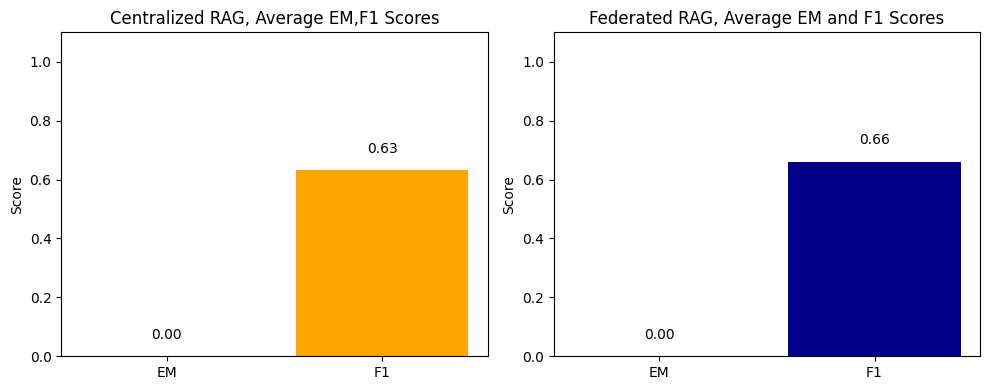

In [ ]:
# Plot average EM & F1 for Centralized RAG vs Federated RAG

plt.figure(figsize=(10, 4))

# Centralized RAG
plt.subplot(1, 2, 1)
bars1 = plt.bar(['EM', 'F1'], [avg_em_trad, avg_f1_trad], color=['lightblue', 'orange'])
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Centralized RAG, Average EM,F1 Scores')
for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + .05, f'{h:.2f}',
             ha='center', va='bottom')

# Federated RAG
plt.subplot(1, 2, 2)
bars2 = plt.bar(['EM', 'F1'], [avg_em_true, avg_f1_true], color=['lightblue', 'darkblue'])
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Federated RAG, Average EM and F1 Scores')
for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + .05, f'{h:.2f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig('Federated_RAG_Comparison_em_f1_average.jpg', format='jpg', dpi=300)
plt.show()

### B. Comparison of Synthesis Capabilities, Comparative Analysis, Completeness of Federated RAG

In [ ]:
def evaluate_synthesis_quality(answer: str, expected: str) -> Dict[str, float]:
    #Evaluate answer quality with metrics of synthesis capabilities.
    """
    Compare generated answer with reference answer on three types:
    1. Synthesis quality    – does the answer has multiple facts together?
    2. Comparative analysis – does it explicitly compare the two universities?
    3. Completeness         – does it cover all key points found in the reference?
    Then Returns a dict containing the three metric scores (0‑1) and a weighted overall score.
    """

    # Synthesis Quality Metrics
    synthesis_score = 0.0
    comparative_score = 0.0
    completeness_score = 0.0

    answer_lower = answer.lower()
    expected_lower = expected.lower()

    # 1. Synthesis Quality (checks for integration of multiple sources)
    synthesis_indicators = ['both', 'while', 'whereas', 'compared to', 'in contrast', 'however', 'although']
    synthesis_count = sum(1 for indicator in synthesis_indicators if indicator in answer_lower)
    synthesis_score = min(synthesis_count / 3.0, 1.0)  # Normalize to 0-1

    # 2. Comparative Analysis (checks for direct comparisons)
    comparative_indicators = ['hull', 'keele', 'vs', 'versus', 'difference', 'similar', 'different']
    comparative_count = sum(1 for indicator in comparative_indicators if indicator in answer_lower)
    comparative_score = min(comparative_count / 4.0, 1.0)  # Normalize to 0-1

    # 3. Completeness (checks for comprehensive coverage)
    key_terms = ['cost', 'price', 'payment', 'start', 'flexible', 'program', 'study']
    expected_terms = [term for term in key_terms if term in expected_lower]
    found_terms = [term for term in expected_terms if term in answer_lower]
    completeness_score = len(found_terms) / max(len(expected_terms), 1)

    # 4. Overall Quality Score (weighted combination)
    overall_score = (synthesis_score * 0.4 + comparative_score * 0.3 + completeness_score * 0.3)

    return {
        'synthesis_quality': synthesis_score,
        'comparative_analysis': comparative_score,
        'completeness': completeness_score,
        'overall_quality': overall_score
    }

def evaluate_approaches():
    # Compare MergerRetriever vs Federated RAG approaches.
    print("\n" + "=" * 80)
    print("EVALUATION: MergerRetriever vs Enhanced Federated RAG")
    print("=" * 80)

    merger_scores = []
    federated_scores = []

    # Evaluate first 5 questions
    for i in range(min(5, len(merger_results), len(federated_results))):
        expected = ground_truth_answers[i]

        # Evaluate RAG with MergerRetriever
        merger_answer = merger_results[i]['answer']
        merger_eval = evaluate_synthesis_quality(merger_answer, expected)
        merger_scores.append(merger_eval)

        # Evaluate Federated RAG
        federated_answer = federated_results[i]['aggregated_answer']
        federated_eval = evaluate_synthesis_quality(federated_answer, expected)
        federated_scores.append(federated_eval)

        print(f"\nQuestion {i+1}: {test_questions[i][:80]}...")
        print(f"Centralized RAG    - Overall: {merger_eval['overall_quality']:.3f}, Synthesis: {merger_eval['synthesis_quality']:.3f}, Comparative: {merger_eval['comparative_analysis']:.3f}")
        print(f"Federated RAG      - Overall: {federated_eval['overall_quality']:.3f}, Synthesis: {federated_eval['synthesis_quality']:.3f}, Comparative: {federated_eval['comparative_analysis']:.3f}")
        print(f"Advantage: {'Federated RAG' if federated_eval['overall_quality'] > merger_eval['overall_quality'] else 'MergerRetriever' if merger_eval['overall_quality'] > federated_eval['overall_quality'] else 'Tie'}")

    # Calculate averages
    avg_merger = {
        metric: sum(score[metric] for score in merger_scores) / len(merger_scores)
        for metric in merger_scores[0].keys()
    }

    avg_federated = {
        metric: sum(score[metric] for score in federated_scores) / len(federated_scores)
        for metric in federated_scores[0].keys()
    }

    print("\n" + "=" * 80)
    print("AVERAGE SCORES (5 Questions)")
    print("=" * 80)
    print(f"{'Metric':<20} {'Centralized RAG':<15} {'Federated RAG':<15} {'Advantage':<15}")
    print("-" * 80)

    for metric in avg_merger.keys():
        merger_val = avg_merger[metric]
        federated_val = avg_federated[metric]
        advantage = 'Federated RAG' if federated_val > merger_val else 'MergerRetriever' if merger_val > federated_val else 'Tie'
        print(f"{metric.replace('_', ' ').title():<20} {merger_val:<15.3f} {federated_val:<15.3f} {advantage:<15}")

    # Overall winner
    overall_winner = 'Federated RAG' if avg_federated['overall_quality'] > avg_merger['overall_quality'] else 'MergerRetriever'
    improvement = abs(avg_federated['overall_quality'] - avg_merger['overall_quality'])

    print("\n" + "=" * 80)
    print(f"OVERALL WINNER: {overall_winner}")
    print(f"Performance Improvement: {improvement:.3f} ({improvement*100:.1f}%)")
    print("=" * 80)

    return avg_merger, avg_federated

# Run evaluation
merger_avg, federated_avg = evaluate_approaches()


EVALUATION: MergerRetriever vs Enhanced Federated RAG

Question 1: Compare the total program costs between Hull's MSc AI Online (£8,950) and Keele'...
Centralized RAG    - Overall: 0.300, Synthesis: 0.000, Comparative: 0.500
Federated RAG      - Overall: 0.775, Synthesis: 1.000, Comparative: 0.750
Advantage: Federated RAG

Question 2: What are all the different pricing options and payment methods available across ...
Centralized RAG    - Overall: 0.483, Synthesis: 0.333, Comparative: 0.500
Federated RAG      - Overall: 0.667, Synthesis: 0.667, Comparative: 1.000
Advantage: Federated RAG

Question 3: Compare the start dates and flexibility between Hull's three annual starts (Janu...
Centralized RAG    - Overall: 0.508, Synthesis: 0.333, Comparative: 0.750
Federated RAG      - Overall: 0.717, Synthesis: 0.667, Comparative: 1.000
Advantage: Federated RAG

Question 4: How do the study durations differ - Hull's structured 2-year part-time vs Keele'...
Centralized RAG    - Overall: 0.775, S

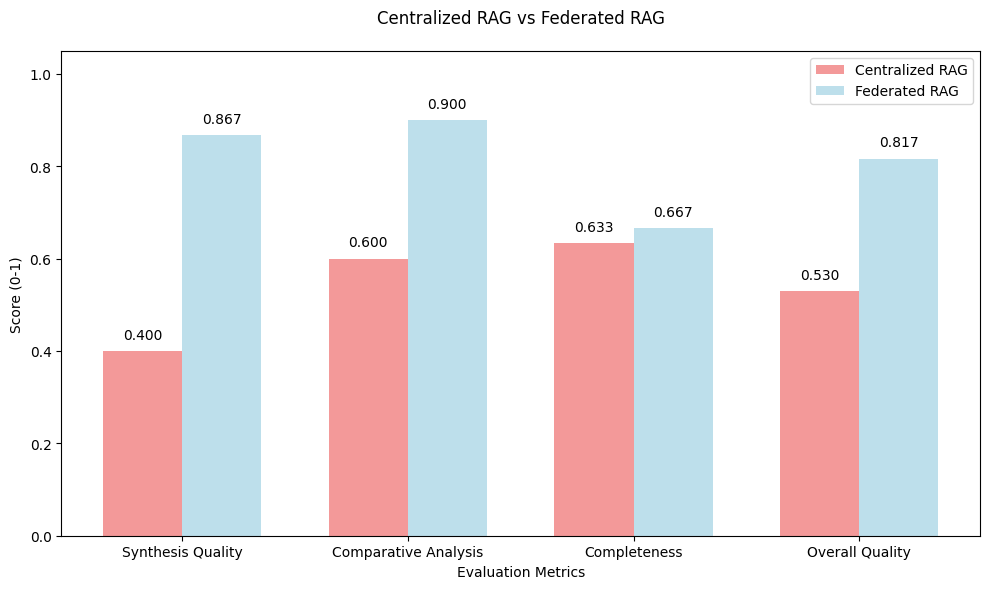

In [ ]:
# Create comparison chart
metrics = ['Synthesis Quality', 'Comparative Analysis', 'Completeness', 'Overall Quality']
merger_values = [merger_avg['synthesis_quality'], merger_avg['comparative_analysis'],
                merger_avg['completeness'], merger_avg['overall_quality']]
federated_values = [federated_avg['synthesis_quality'], federated_avg['comparative_analysis'],
                   federated_avg['completeness'], federated_avg['overall_quality']]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, merger_values, width, label='Centralized RAG', color='lightcoral', alpha=0.8)
bars2 = ax.bar(x + width/2, federated_values, width, label='Federated RAG', color='lightblue', alpha=0.8)

ax.set_xlabel('Evaluation Metrics')
ax.set_ylabel('Score (0-1)')
ax.set_title('Centralized RAG vs Federated RAG', pad=20)  # Added pad=20
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.05)  # Extended from 1.0 to 1.05 to provide space for labels

def autolabel(bars):
    for bar in bars:
        height = bar.get_height()

        # If bar is very high (>0.95), place label inside the bar to prevent cutoff
        if height > 0.95:
            label_y = height - 0.05  # Place inside the bar
            label_color = 'white'
            font_weight = 'bold'
            va_align = 'center'
        else:
            label_y = height + 0.02  # Place above the bar
            label_color = 'black'
            font_weight = 'normal'
            va_align = 'bottom'

        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, label_y),
                    ha='center', va=va_align,
                    color=label_color,
                    fontweight=font_weight)

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
fig.savefig("rag_comparison.jpeg", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


# **Conclusion**
# **Federated RAG Outperforms Centralized RAG**

SUPERIOR SYNTHESIS shown that Federated RAG's coordinator could combines information from multiple nodes, producing coherent **comparative analysis**.

COMPARATIVE ANALYSIS is for cross-institutional comparisons with contextual understanding of different sources.

COMPREHENSIVE exploration to ensuring relevant sources are synthesized, instead of randomly merged document chunks.

PRIVACY SAFEGUARDS which Maintains data privacy, original datasets never leave their home nodes while enabling analysis across different sources.

CONTEXTUAL INTELLIGENCE to better understanding of question to more relevant responses,  generating context-aware responses that centralized retrieval cannot match.


# **Reason Federated RAG is Better than Centralized RAG with MergerRetriever**


1. It can combine answers from many sources without putting them all in one place.

2. It’s good at collecting and organizing information from different places.

3. It can give smarter recommendations by looking at the full context.

4. It can analyze things from many angles (like comparing schools, policies,  research, etc).

5. It keeps data private, so raw information isn’t shared.


# **Federated RAG is useful for:**

- Comparing programs.

- Comparing competitors.

- Making policies that involve many groups.

- Any situation where we need cross-source analysis but must keep data private.
